<a href="https://colab.research.google.com/github/ALAAMEKAWY56/chest-xray-pneumonia-CNN/blob/main/Chest_X_Ray_Images_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pneumonia Detection from Chest X-Rays — CNN Pipeline

Binary image classification: **NORMAL** vs **PNEUMONIA** on the Kaggle
*Chest X-Ray Images (Pneumonia)* dataset (pediatric patients, 1–5 years old,
anterior-posterior view).

This notebook walks the full pipeline: EDA → data preparation → a CNN from
scratch → training → evaluation → an optional transfer-learning upgrade.

**Three things about this dataset that trip people up — handled below:**
1. The official `val` folder has only **16 images**. It is useless for model
   selection, so we ignore it and carve a proper validation split out of `train`.
2. The training set is **imbalanced** (~74% pneumonia). Accuracy alone is
   misleading — we use recall, precision, F1, and AUC, and pass `class_weight`.
3. It's **pediatric** data. A model trained here will not generalize to adult
   chest X-rays. Frame any results honestly.

In [27]:
import tensorflow as tf
import plotly.express as px
import os
from tensorflow.keras import layers, models
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

In [3]:
!pip install kaggle==1.6.17

os.environ['KAGGLE_USERNAME'] = 'alaaMekawi'
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_ea37d9513d5193731300f4922cc08612'


!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia


!unzip -nq chest-xray-pneumonia.zip -d chest-xray-pneumonia_colab

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for kaggle: filename=kaggle-1.6.17-py3-none-any.whl size=105787 sha256=df88ecd70a391962ccb17de9f0774be2f247ec05e79e055041f39ef96c15aca5
  Stored in directory: /root/.cache/pip/wheels/46/d2/26/84d0a1acdb9c6baccf7d28cf06962ec80529fe1ad938489983
Successfully built kaggle
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 99% 2.28G/2.29G [00:14<00:00, 224MB/s]
100% 2.29G/2.29G [00:14<00:00, 166MB/s]


In [4]:
!find chest-xray-pneumonia_colab -maxdepth 2 -type d


chest-xray-pneumonia_colab
chest-xray-pneumonia_colab/chest_xray
chest-xray-pneumonia_colab/chest_xray/test
chest-xray-pneumonia_colab/chest_xray/chest_xray
chest-xray-pneumonia_colab/chest_xray/__MACOSX
chest-xray-pneumonia_colab/chest_xray/val
chest-xray-pneumonia_colab/chest_xray/train


In [5]:
BASE_DIR = "/content/chest-xray-pneumonia_colab/chest_xray"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")
TEST_DIR = os.path.join(BASE_DIR, "test")

In [6]:
for name, path in [("TRAIN", TRAIN_DIR), ("VAL", VAL_DIR), ("TEST", TEST_DIR)]:
    print(name, os.path.isdir(path), path)

TRAIN True /content/chest-xray-pneumonia_colab/chest_xray/train
VAL True /content/chest-xray-pneumonia_colab/chest_xray/val
TEST True /content/chest-xray-pneumonia_colab/chest_xray/test


### Configuration constants

| Constant | Value | Why |
|---|---|---|
| `IMAGE_SIZ` | `(224, 224)` | All X-rays are resized to this fixed shape (they vary in the raw data). 224×224 matches pretrained ImageNet models, so a transfer-learning backbone can be added later without changing the pipeline. |
| `BATCH_SIZE` | `32` | Number of images processed per training step. A standard default that balances stable gradient estimates against GPU memory. |
| `SEED` | `42` | Fixes randomness (train/validation split, shuffling, augmentation) so runs are reproducible. |

In [7]:
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

## 1. Exploratory Data Analysis

Goal: understand class balance, what the images look like, and confirm they
vary in size (so resizing is mandatory).

In [8]:
def count_images(directory):
  # Empty dictionary
  counts = {}

  # Loop over the directory
  for cls in sorted(os.listdir(directory)):
    cls_path = os.path.join(directory, cls)
    if os.path.isdir(cls_path):
      counts[cls] = len(os.listdir(cls_path))

  return counts

In [9]:
for split , path in [("train" , TRAIN_DIR) , ("val" , VAL_DIR) , ("test" , TEST_DIR)]:
  print(f"{split:6}", count_images(path))

train  {'NORMAL': 1341, 'PNEUMONIA': 3875}
val    {'NORMAL': 8, 'PNEUMONIA': 8}
test   {'NORMAL': 234, 'PNEUMONIA': 390}


### Imbalanced training data

The training set is imbalanced **~74% pneumonia (3,875) vs ~26% normal (1,341)**,
nearly 3:1. Because of this, I use **`class_weight`** during training to stop the
model favoring the majority class, and I evaluate with **recall, F1, and AUC**
rather than accuracy (a model guessing "pneumonia" every time would score ~74%
accuracy while being useless).

In [10]:
train_counts = count_images(TRAIN_DIR)
fig = px.bar(x = list(train_counts.keys()) , y = list(train_counts.values()),
    text=list(train_counts.values()),
    color=list(train_counts.keys()),
    title="Training set: class distribution",
    labels={"x": "Class", "y": "Number of images"},
    template="simple_white")
fig.show()

## 2. Data Preparation

**The key decision:** we re-split the `train` folder 80/20 into train/validation
(stratified by class via `image_dataset_from_directory`) and keep the `test`
folder as the untouched held-out set. The tiny official `val` folder is ignored.

We load as RGB at 224×224 so the same pipeline feeds both the from-scratch CNN
and the pretrained model later. (X-rays are grayscale — `color_mode='grayscale'`
with a 1-channel input is a valid, lighter alternative for the from-scratch model.)

In [11]:
# TRAIN, 80% of the train folder
train_ds = tf.keras.utils.image_dataset_from_directory(
 TRAIN_DIR,
 validation_split=0.2,
 subset="training",
 seed= SEED,
 image_size = IMAGE_SIZE,
 batch_size = BATCH_SIZE,
 label_mode = "binary")

# VALIDATION, the other 20% of the SAME train folder (same seed!)
val_ds = tf.keras.utils.image_dataset_from_directory(
 TRAIN_DIR,
 validation_split=0.2,
 subset="validation",
 seed= SEED,
 image_size = IMAGE_SIZE,
 batch_size = BATCH_SIZE,
 label_mode = "binary")

# TEST, load the whole folder, no splitting
test_ds = tf.keras.utils.image_dataset_from_directory(
 TEST_DIR,
 seed= SEED,
 image_size = IMAGE_SIZE,
 batch_size = BATCH_SIZE,
 shuffle=False,
 label_mode = "binary")

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.


In [12]:
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['NORMAL', 'PNEUMONIA']


## 3. Data Augmentation

To reduce overfitting on our small (~5k image) dataset, I apply light random
transformations to the training images. Each epoch the model sees slightly
altered versions mildly rotated, zoomed, and shifted, So it learns robust
features instead of memorizing exact pixels.

- **`RandomRotation(0.05)`**: rotates up to ±5% of a turn (≈ ±18°)
- **`RandomZoom(0.1)`**: zooms in/out by up to 10%
- **`RandomTranslation(0.05, 0.05)`**: shifts up to 5% horizontally and vertically

Augmentation runs **only during training**; validation and test images are left
untouched.

In [13]:
data_agumentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
],
name = "agumentation")

## 4. Handle Class Imbalance

The training set is ~3:1 pneumonia-to-normal, so the model could score well by
just favoring the majority class. To counter this, I compute **class weights**
using the standard balanced formula `total / (2 × class_count)`:

- **NORMAL (0):** ≈ 1.95 — the rarer class, weighted *up*
- **PNEUMONIA (1):** ≈ 0.67 — the common class, weighted *down*



In [14]:
neg , pos = train_counts["NORMAL"] , train_counts["PNEUMONIA"]
total = neg + pos
class_weight = {0: total / (2 * neg) , 1: total / (2 * pos)}
print(class_weight)

{0: 1.9448173005219984, 1: 0.6730322580645162}


## 5. Build the CNN (from scratch)

Four Conv → BatchNorm → MaxPool blocks with a growing filter count, then global
average pooling and a small dense head. Output is a single sigmoid unit for
binary classification. Augmentation and rescaling live *inside* the model so
inference gets the same preprocessing automatically.

In [ ]:
model= models.Sequential([
    layers.Input(shape = (224 , 224 , 3) , name = 'Input_layer'),
    data_agumentation,
    layers.Rescaling(1./255),

    # First Block of convoultional netwrok
    layers.Conv2D(32 , (3,3) , padding = 'same' , activation="relu",  name = 'CNN_layer_1'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),


    layers.Conv2D(64 , (3,3) , padding = 'same'  , activation="relu" , name = 'CNN_layer_2'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Double the kernel filters every time
    # Second Block of convoultional netwrok
    layers.Conv2D(128 , (3,3) , padding = 'same'  , activation="relu" , name = 'CNN_layer_3'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128 , (3,3) , padding = 'same'  , activation="relu" , name = 'CNN_layer_4'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Flattening
    layers.GlobalAveragePooling2D(),

    # Predicition
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

In [ ]:
model.summary()

In [ ]:
optimizer = Adam(learning_rate = 0.0005)

In [ ]:
model.compile(optimizer= optimizer , loss = 'binary_crossentropy'
, metrics = ['accuracy',
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall"),
             tf.keras.metrics.AUC(name="auc")])

## 6. Train

`class_weight` counters the imbalance.

In [ ]:
from IPython.core import history

In [ ]:
history = model.fit(
    train_ds, validation_data=val_ds,
    epochs=25, class_weight=class_weight)

In [ ]:
def plot_loss_acc_recall(history, trial_number , model_name='model_1'):
    print(f"Trial number is {trial_number}")
    plt.title(f"Loss - {model_name}")
    plt.plot(history.history['loss'], c='red', label='train_loss')
    plt.plot(history.history['val_loss'], c='green', label='valid_loss')
    plt.legend()
    plt.show()

    plt.title(f"Accuracy - {model_name}")
    plt.plot(history.history['accuracy'], c='red', label='train_accuracy')
    plt.plot(history.history['val_accuracy'], c='green', label='valid_accuracy')
    plt.legend()
    plt.show()

    plt.title(f"Recall - {model_name}")
    plt.plot(history.history['recall'], c='red', label='train_recall')
    plt.plot(history.history['val_recall'], c='green', label='valid_recall')
    plt.legend()
    plt.show()


plot_loss_acc_recall(history,trial_number = 1, model_name='Chest_xray_detector_CNN')

# 7. Trial 2 Chest X-Ray Detector CNN

## Changes from Trial 1

| Parameter | Trial 1 | Trial 2 |
|---|---|---|
| Dropout (Dense layers) | 0.3 | 0.5 |
| Dropout (Conv blocks) | None | 0.25 |
| Learning Rate | Default (0.001) | 0.0001 |

## Hypothesis

Trial 1 showed clear overfitting and training instability val loss spiked to 6+ and val recall crashed to 0 at multiple epochs. The goal of Trial 2 is to:

- **Reduce overfitting** by increasing dropout from 0.3  0.5 in dense layers and adding 0.25 dropout after conv blocks
- **Stabilize training** by lowering the learning rate from 0.001 to 0.0001, which should smooth out the validation spikes

In [15]:
model= models.Sequential([
    layers.Input(shape = (224 , 224 , 3) , name = 'Input_layer'),
    data_agumentation,
    layers.Rescaling(1./255),

    # First Block of convoultional netwrok
    layers.Conv2D(32 , (3,3) , padding = 'same' , activation="relu",  name = 'CNN_layer_1'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),


    layers.Conv2D(64 , (3,3) , padding = 'same'  , activation="relu" , name = 'CNN_layer_2'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Double the kernel filters every time
    # Second Block of convoultional netwrok
    layers.Conv2D(128 , (3,3) , padding = 'same'  , activation="relu" , name = 'CNN_layer_3'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128 , (3,3) , padding = 'same'  , activation="relu" , name = 'CNN_layer_4'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Flattening
    layers.GlobalAveragePooling2D(),

    # Predicition
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])

In [29]:
model.compile(optimizer= Adam(learning_rate=0.0003) , loss = 'binary_crossentropy'
, metrics = ['accuracy',
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall"),
             tf.keras.metrics.AUC(name="auc")])

In [30]:
# 3. Add callbacks to stabilize
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping



callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

In [31]:
history = model.fit(
    train_ds, validation_data=val_ds,
    epochs=25, class_weight=class_weight,
    callbacks = callbacks)

Epoch 1/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 38s 248ms/step - accuracy: 0.8699 - auc: 0.9436 - loss: 0.2924 - precision: 0.9700 - recall: 0.8500 - val_accuracy: 0.2589 - val_auc: 0.5742 - val_loss: 6.5863 - val_precision: 1.0000 - val_recall: 0.0264 - learning_rate: 3.0000e-04
Epoch 2/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 33s 254ms/step - accuracy: 0.8862 - auc: 0.9560 - loss: 0.2617 - precision: 0.9755 - recall: 0.8676 - val_accuracy: 0.3739 - val_auc: 0.8319 - val_loss: 1.5660 - val_precision: 0.9930 - val_recall: 0.1788 - learning_rate: 3.0000e-04
Epoch 3/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 37s 280ms/step - accuracy: 0.8859 - auc: 0.9530 - loss: 0.2702 - precision: 0.9700 - recall: 0.8724 - val_accuracy: 0.3586 - val_auc: 0.9020 - val_loss: 1.9263 - val_precision: 1.0000 - val_recall: 0.1574 - learning_rate: 3.0000e-04
Epoch 4/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 33s 248ms/step - accuracy: 0.8917 - auc: 0.9601 - loss: 0.2512 - precision: 0.9727 - recall: 0.8780 - val_accuracy: 0.3375 - val_auc: 0.9434 

Trial number is 2


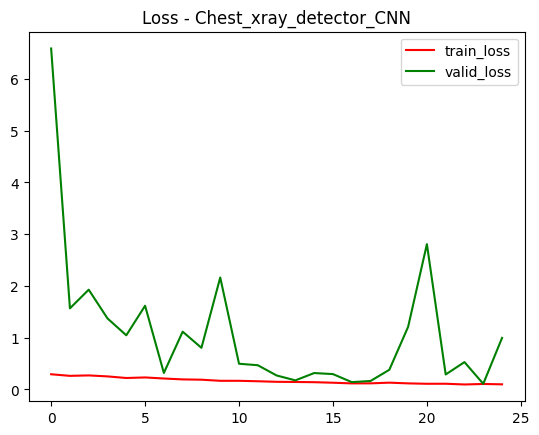

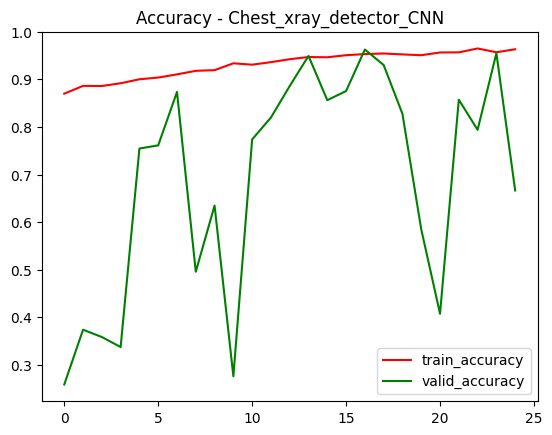

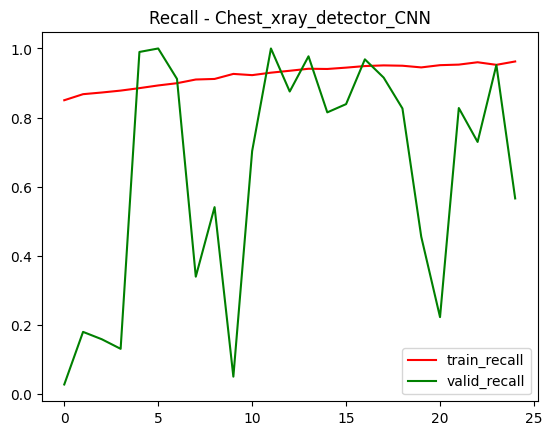

In [32]:
def plot_loss_acc_recall(history, trial_number , model_name='model_1'):
    print(f"Trial number is {trial_number}")
    plt.title(f"Loss - {model_name}")
    plt.plot(history.history['loss'], c='red', label='train_loss')
    plt.plot(history.history['val_loss'], c='green', label='valid_loss')
    plt.legend()
    plt.show()

    plt.title(f"Accuracy - {model_name}")
    plt.plot(history.history['accuracy'], c='red', label='train_accuracy')
    plt.plot(history.history['val_accuracy'], c='green', label='valid_accuracy')
    plt.legend()
    plt.show()

    plt.title(f"Recall - {model_name}")
    plt.plot(history.history['recall'], c='red', label='train_recall')
    plt.plot(history.history['val_recall'], c='green', label='valid_recall')
    plt.legend()
    plt.show()

plot_loss_acc_recall(history,trial_number = 2, model_name='Chest_xray_detector_CNN')

# 8. Visualize Predictions

Display 10 sample images from the validation set with their **true** and **predicted** labels.  
Titles appear in **green** if correct, **red** if wrong.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


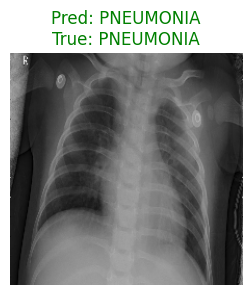

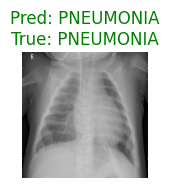

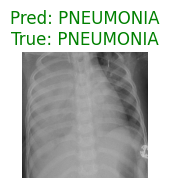

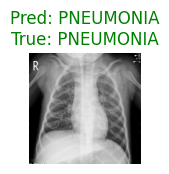

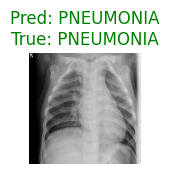

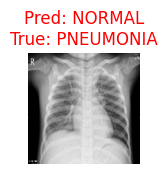

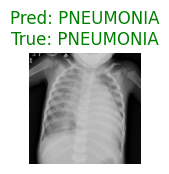

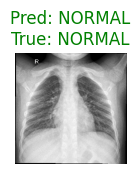

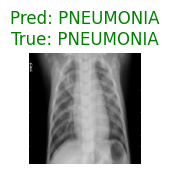

In [36]:
for images , labels in val_ds.take(1):
  # Predict batch of images
  preds = model.predict(images)
  # Flatten
  pred_probs = preds.ravel()
  # Convert probabilities to decisions
  pred_labels = (pred_probs >= 0.5).astype(int)

  plt.figure(figsize =(12 , 8))
  for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = images[i].numpy() / 255.0
    plt.imshow(img)
    true_label = class_names[int(labels[i])]
    pred_label = class_names[pred_labels[i]]
    color = "green" if true_label == pred_label else "red"

    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 9. Evaluate on Test Set

Run the final evaluation on the **unseen test set** (624 images, never touched during training).

- **Classification Report**: precision, recall, F1 for each class
- **ROC-AUC**: overall discrimination ability regardless of threshold
- **Confusion Matrix**: visual breakdown of correct vs incorrect predictions

> The most critical metric for this task is **Recall on PNEUMONIA** missing a sick patient is far more dangerous than a false alarm.

              precision    recall  f1-score   support

      NORMAL       0.96      0.79      0.87       234
   PNEUMONIA       0.89      0.98      0.93       390

    accuracy                           0.91       624
   macro avg       0.92      0.89      0.90       624
weighted avg       0.91      0.91      0.91       624

ROC-AUC: 0.9574


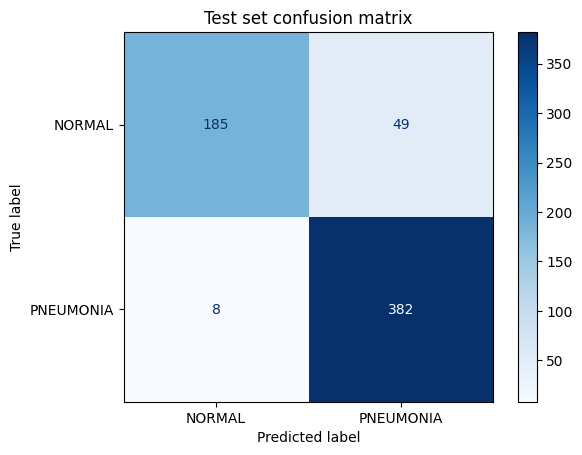

In [40]:
y_true = []
y_prob = []

for images ,labels in test_ds:
  y_true.extend(labels.numpy())
  y_prob.extend(model.predict(images , verbose = 0).ravel())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)


# Results
print(classification_report(y_true, y_pred, target_names=class_names))
print("ROC-AUC:", round(roc_auc_score(y_true, y_prob), 4))


# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues")
plt.title("Test set confusion matrix")
plt.show()